要绘制 3D 图形，您必须显式地引入 mpl_toolkits.mplot3d
extension modules for the Matplotlib plotting library mpl_toolkits.mplot3d.

https://chat.deepseek.com/a/chat/s/81b7383a-cce9-4fbe-b3f7-fbdab4a5cd33

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# 导入 3D 绘图工具包（必须导入，但不需要显式调用）
from mpl_toolkits.mplot3d import Axes3D

屏幕分辨率 (DPI) 差异（主要原因）Matplotlib 默认 DPI： Matplotlib 在计算输出图形的像素大小时，默认使用 DPI (Dots Per Inch) 100。因此，一个 10 \times 8 英寸的图形，它在内存中渲染出的像素大小是：10 \times 100 像素宽 \times 8 \times 100 像素高 \approx 1000 \times 800 像素。屏幕 DPI： 您的电脑屏幕（尤其是高分屏或 Retina 屏）的实际 DPI 远远高于 100（通常是 150 到 300 DPI）。

In [ ]:
# 在 Notebook 的一个单元格中运行此行
# 'retina' 会生成高分辨率的图片，强制浏览器将其渲染得更大、更清晰。
%config InlineBackend.figure_format = 'retina'

基础 3D 绘图
开始使用 Matplotlib 进行 3D 绘图，需要先搭建一个 3D 绘图环境，然后就可以绘制一些基础的图形了。

搭建 3D 绘图环境
在绘制任何 3D 图形之前，都需要先导入必要的库，并创建一个具有 3D 投影的坐标轴对象。这是所有 3D 绘图的基础：

python

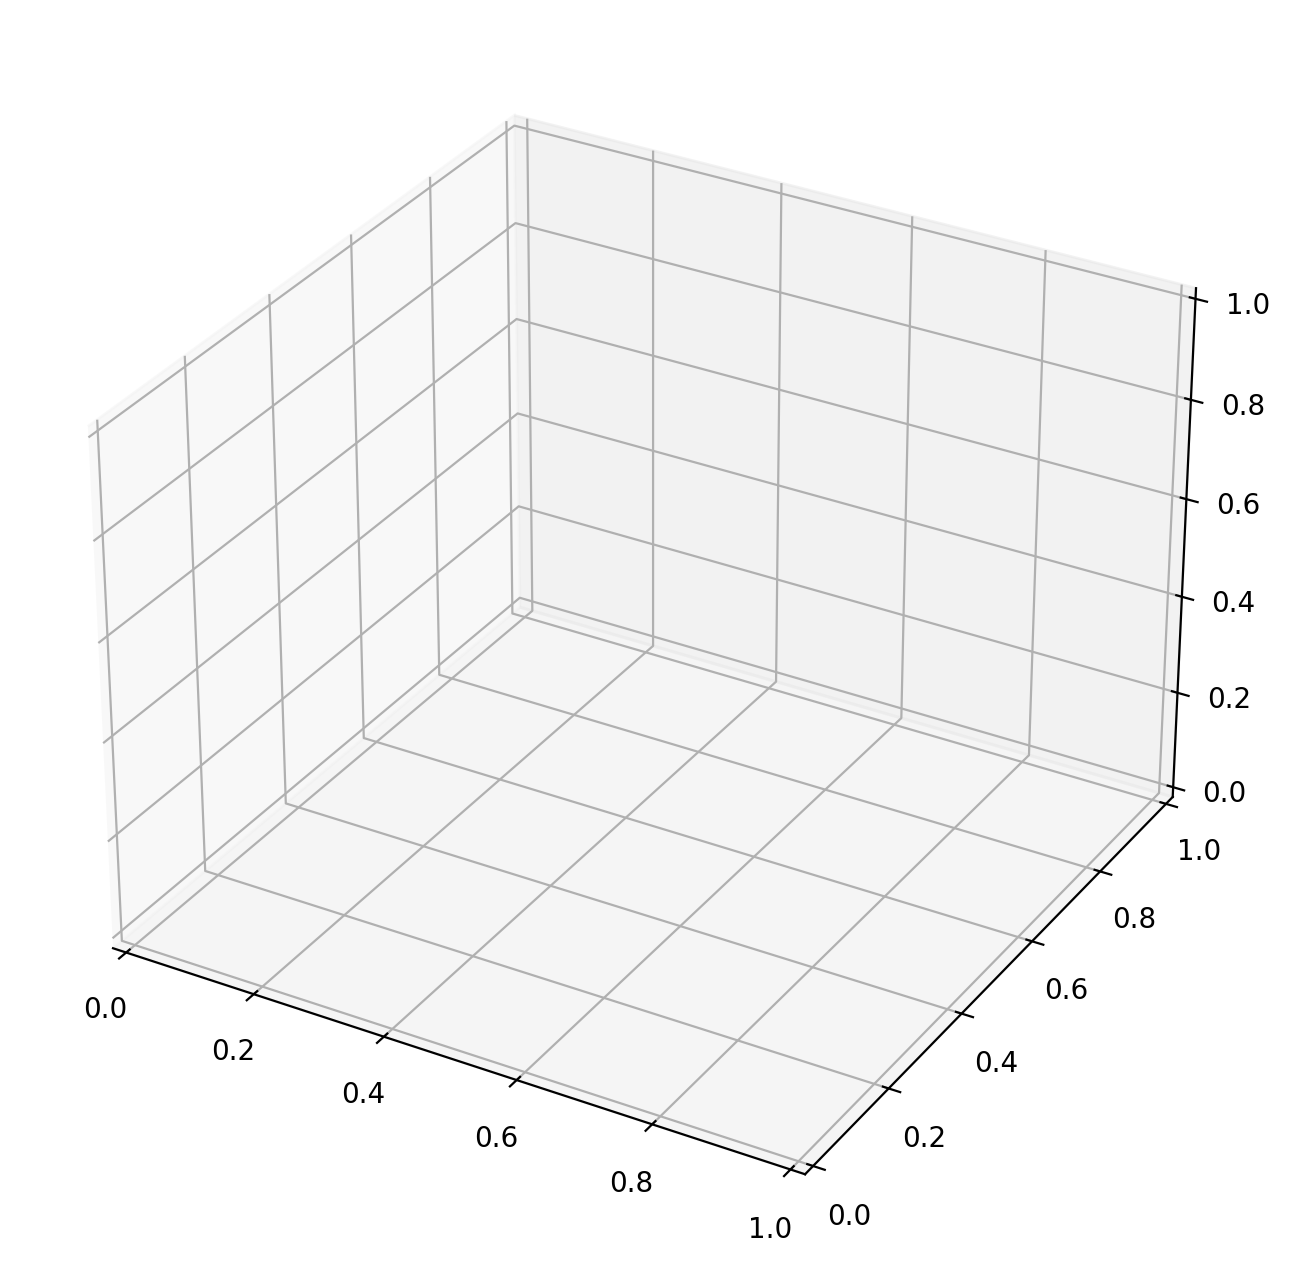

In [ ]:
# 建议设置一个较大的图形尺寸 (figsize)
fig = plt.figure(figsize=(10, 8)) # 10 x 8 inches, 100 dpi -> 1000 x 800 pixels (default) in ipynb 

# 核心代码：创建 3D 坐标轴
# projection='3d' 是激活 3D 模式的关键
ax = fig.add_subplot(111, projection='3d')

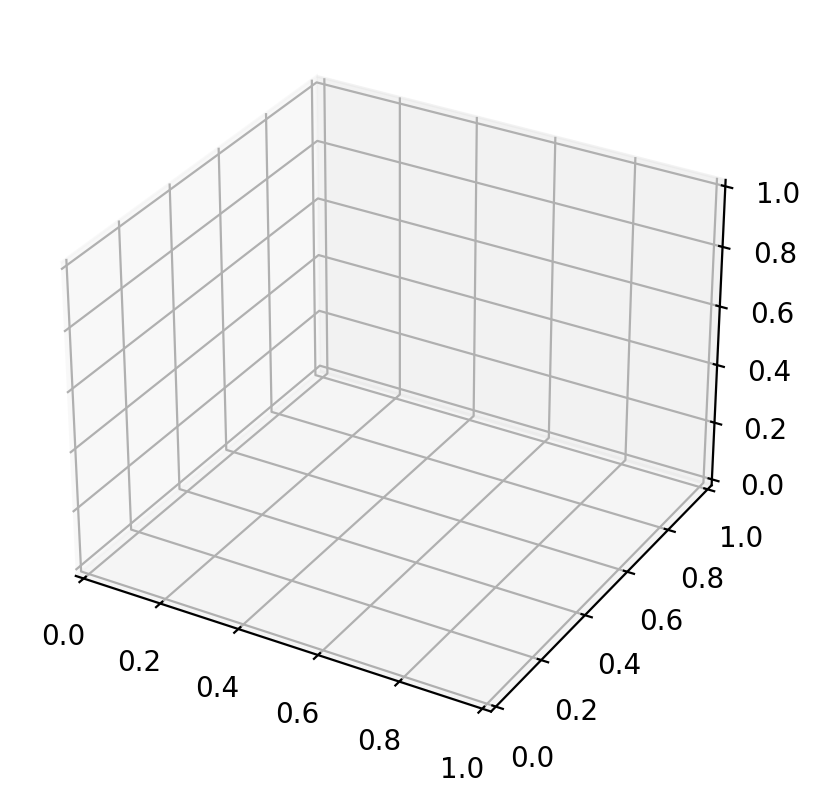

In [10]:
# 导入必要的库
import matplotlib.pyplot as plt
import numpy as np
# 为了支持3D绘图，需要从mpl_toolkits.mplot3d导入Axes3D。
# 注意：对于较新的Matplotlib版本（3.2.0以上），即使不显式导入Axes3D，也可能正常使用，但建议保留导入。
from mpl_toolkits.mplot3d import Axes3D

# 创建图形和3D坐标轴
fig = plt.figure() # 创建一个新的图形窗口
ax = fig.add_subplot(111, projection='3d') # 添加一个子图，并指定为3D投影

# 现在，变量 ax 就是一个3D坐标轴对象，我们可以用它来绘制各种3D图形

绘制 3D 线图 📈
3D 线图可以用来绘制空间中的曲线或轨迹。使用 ax.plot() 函数，并传入三组分别代表 X、Y、Z 坐标的一维数组即可

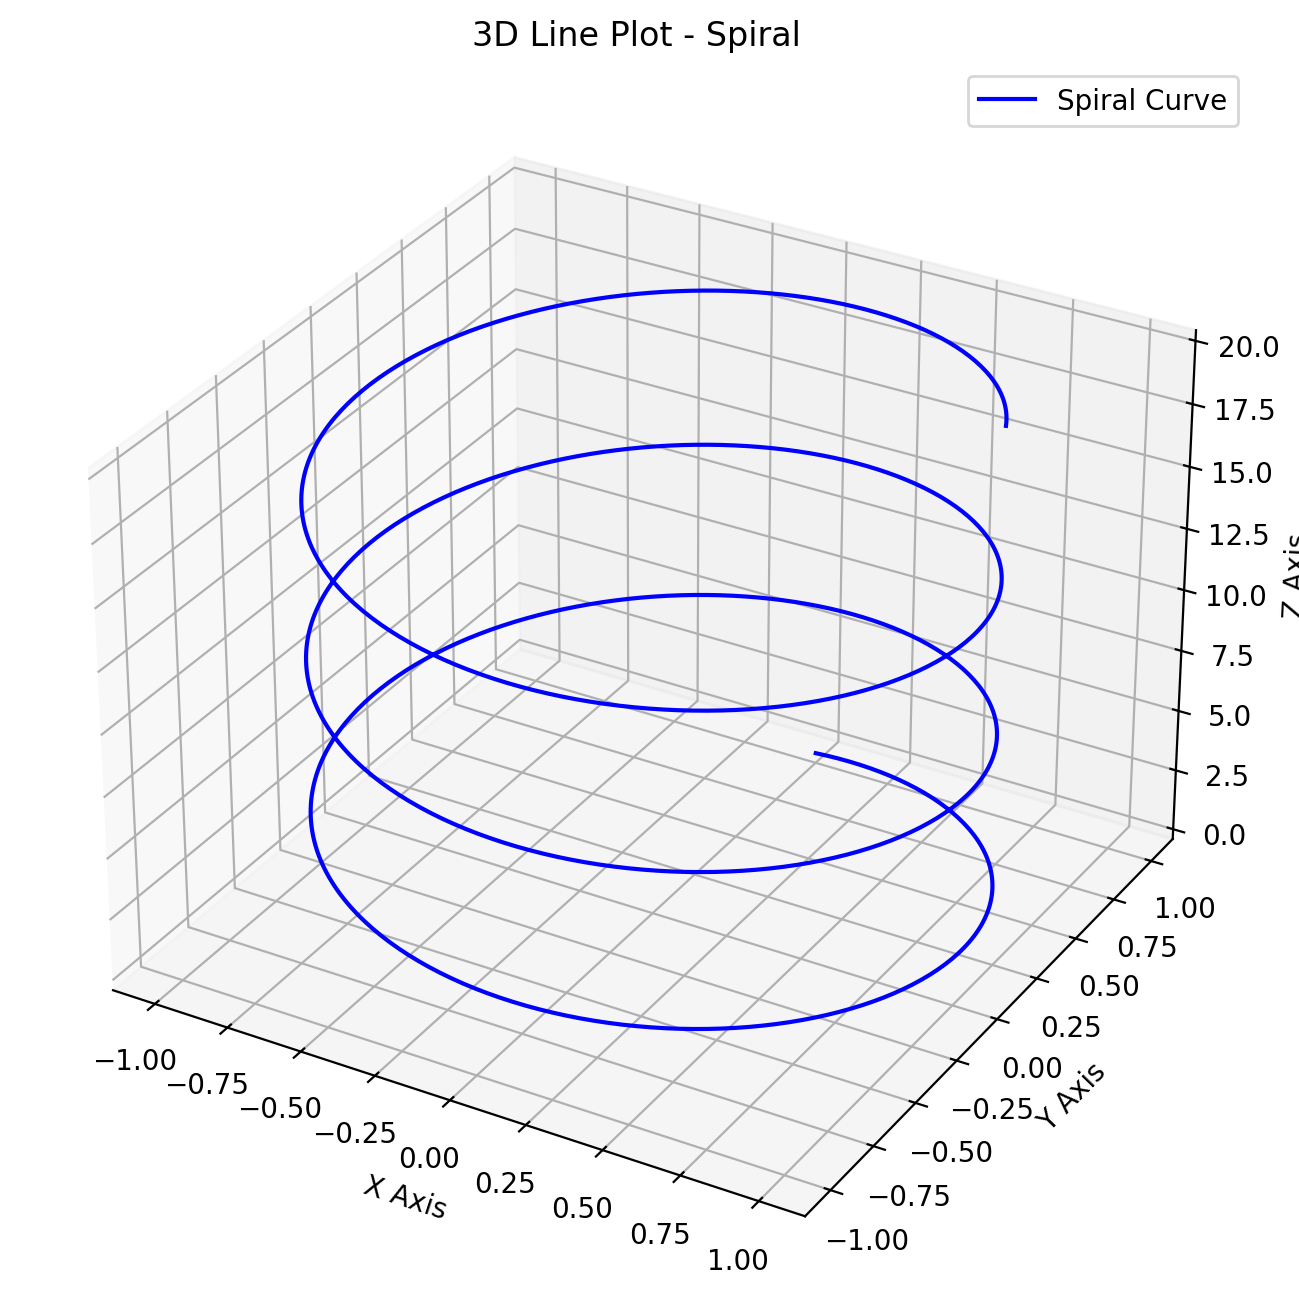

In [11]:
# 生成示例数据：一条螺旋线
t = np.linspace(0, 20, 1000) # 生成一个从0到20的等间距数组，包含1000个点
x = np.sin(t) # x坐标按正弦变化
y = np.cos(t) # y坐标按余弦变化
z = t # z坐标线性增长

# 创建图形和3D坐标轴
fig = plt.figure(figsize=(10, 8)) # 可以指定图形大小
ax = fig.add_subplot(111, projection='3d')

# 绘制3D线图
ax.plot(x, y, z, color='blue', linewidth=1.5, label='Spiral Curve')

# 添加坐标轴标签
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

# 添加标题
ax.set_title('3D Line Plot - Spiral')

# 显示图例
ax.legend()

# 显示图形
plt.show()

绘制 3D 散点图 • • •
3D 散点图适用于展示三维空间中的数据点分布。使用 ax.scatter() 函数

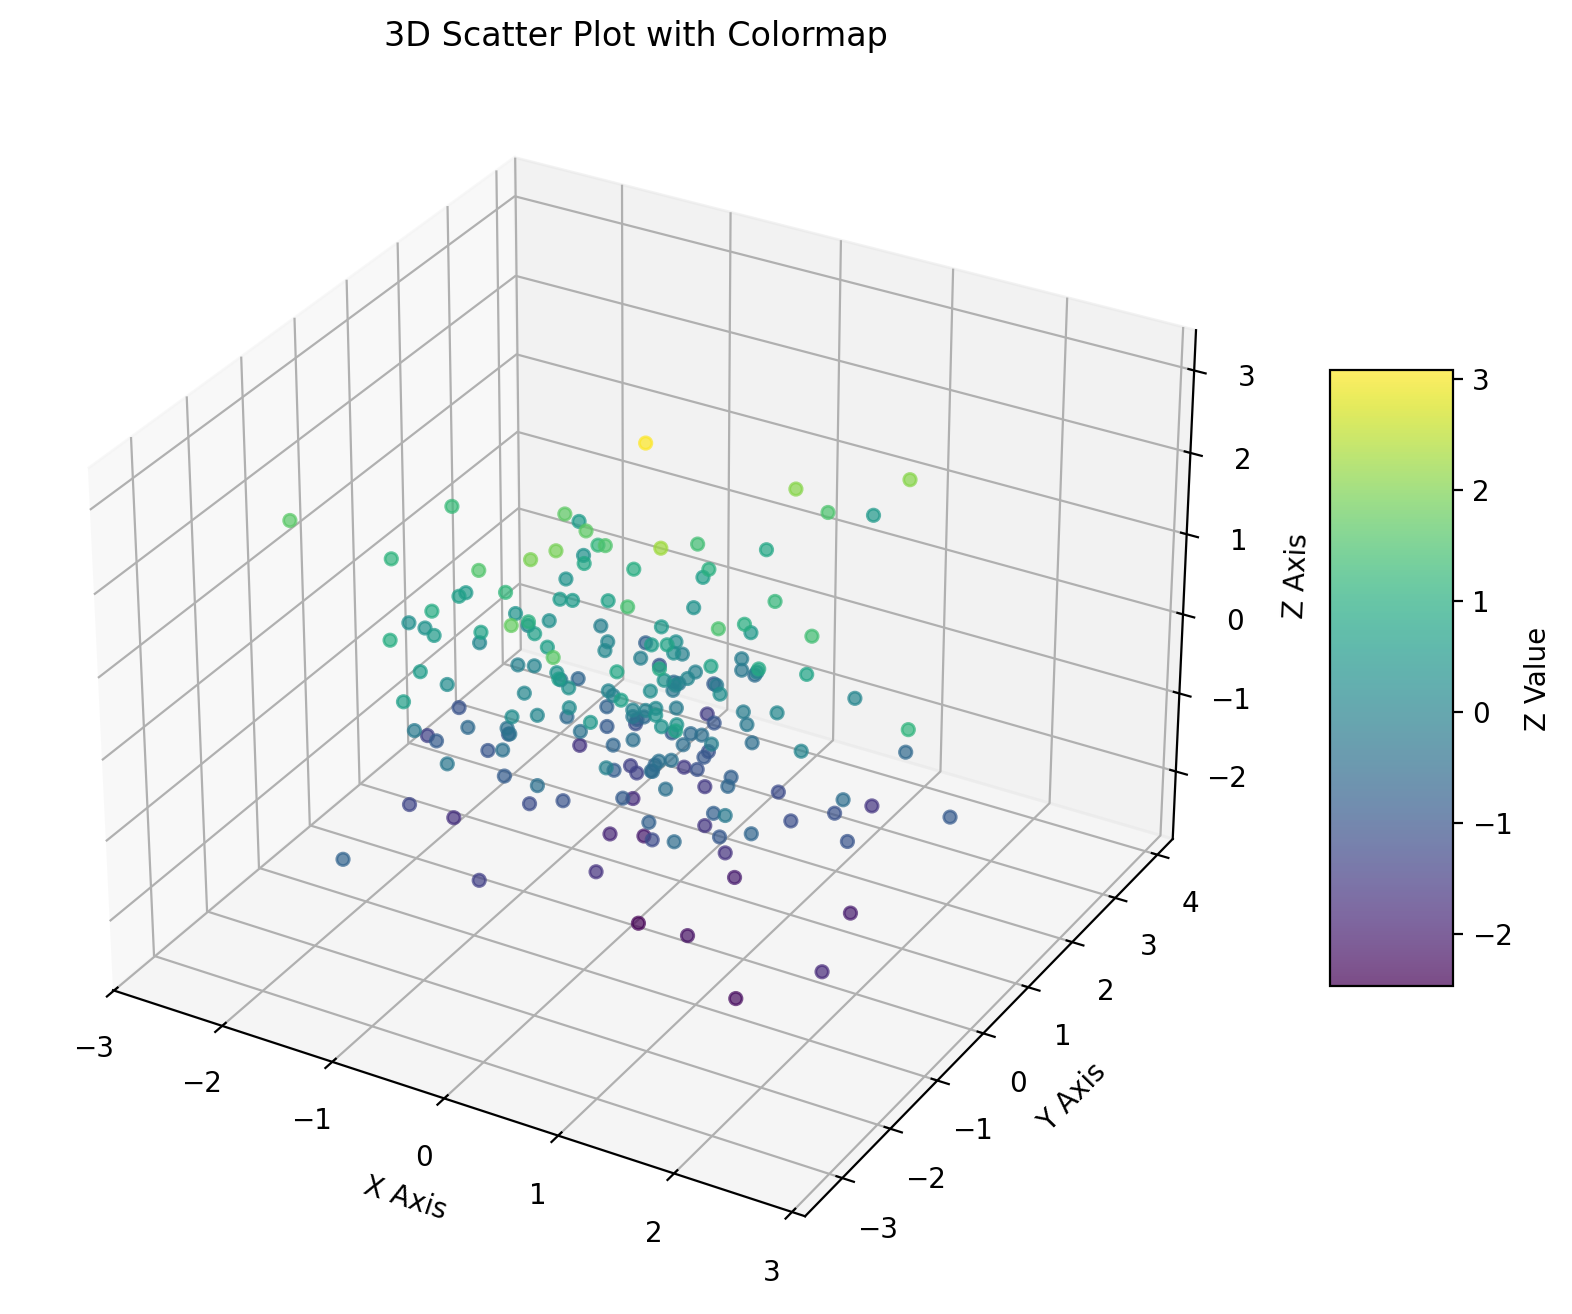

In [ ]:
# 生成随机散点数据
np.random.seed(42) # 设置随机种子以便重现结果
num_points = 200
x = np.random.randn(num_points) # 生成服从标准正态分布的随机数作为x坐标
y = np.random.randn(num_points) # y坐标
z = np.random.randn(num_points) # z坐标

# 创建图形和3D坐标轴
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制3D散点图
# 参数 c 可以指定颜色，cmap 指定颜色映射，s 指定点的大小
scatter = ax.scatter(x, y, z, c=z, cmap='viridis', s=20, alpha=0.7) # alpha控制透明度

# 添加颜色条，表示Z值的大小
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=5, label='Z Value')

# 添加坐标轴标签和标题
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('3D Scatter Plot with Colormap')

plt.show()

绘制 3D 曲面图 🗻
曲面图非常适合展示二维函数在三维空间中的形态。绘制曲面图需要用到 ax.plot_surface() 函数，并且数据通常需要准备成网格（meshgrid）形式

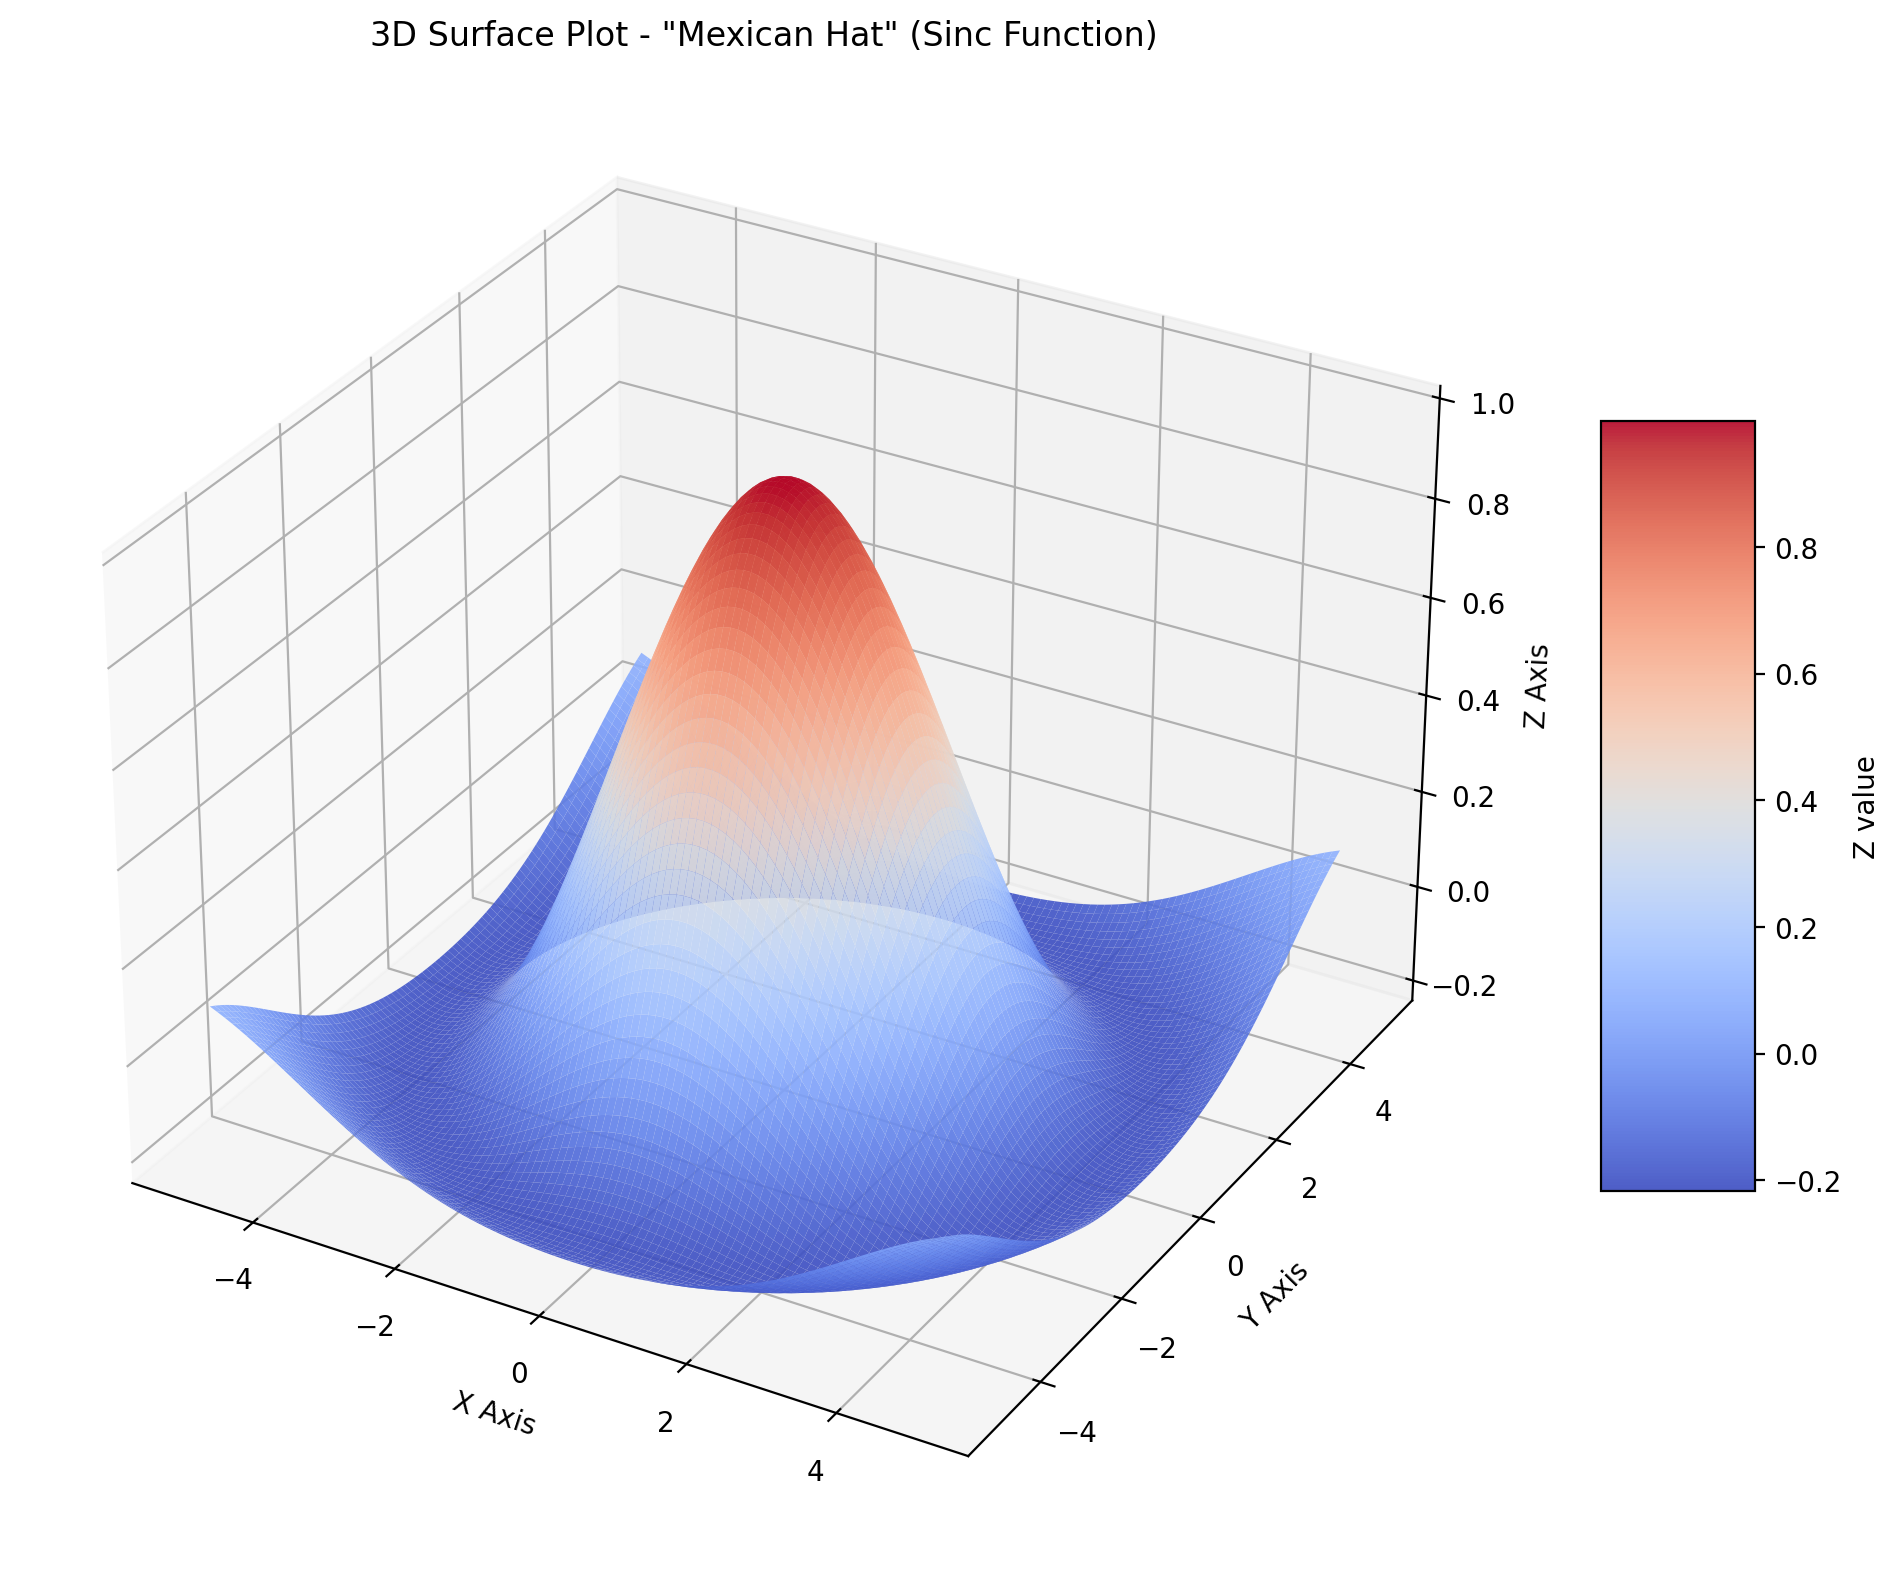

In [ ]:
# 生成网格数据
x = np.linspace(-5, 5, 100) # 在-5到5范围内生成100个点
y = np.linspace(-5, 5, 100) 
X, Y = np.meshgrid(x, y) # 将x, y坐标转换为网格矩阵 <<<======================   


# 计算每个网格点上的Z值：这里以墨西哥帽函数为例
R = np.sqrt(X**2 + Y**2) # 计算到原点的距离
Z = np.sin(R) / R # 墨西哥帽函数 (sinc函数)
Z = np.nan_to_num(Z) # 处理原点处可能出现的NaN值

# 创建图形和3D坐标轴
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 绘制3D曲面图
# 参数 cmap 指定颜色映射，rstride 和 cstride 控制行和列的采样步长（已不推荐，推荐使用rcount, ccount）
# antialiased 控制抗锯齿
surface = ax.plot_surface(X, Y, Z, cmap='coolwarm', rcount=100, ccount=100, 
                         linewidth=0, antialiased=True, alpha=0.9)

# 添加颜色条
cbar = fig.colorbar(surface, ax=ax, shrink=0.5, aspect=5, label='Z value')

# 添加坐标轴标签和标题
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('3D Surface Plot - "Mexican Hat" (Sinc Function)')

plt.show()

In [ ]:
print( X, Y, Z)

绘制 3D 等高线图 🗺️
3D 等高线图可以将三维数据以等高线的形式投影到不同的平面上。使用 ax.contour3D() 函数

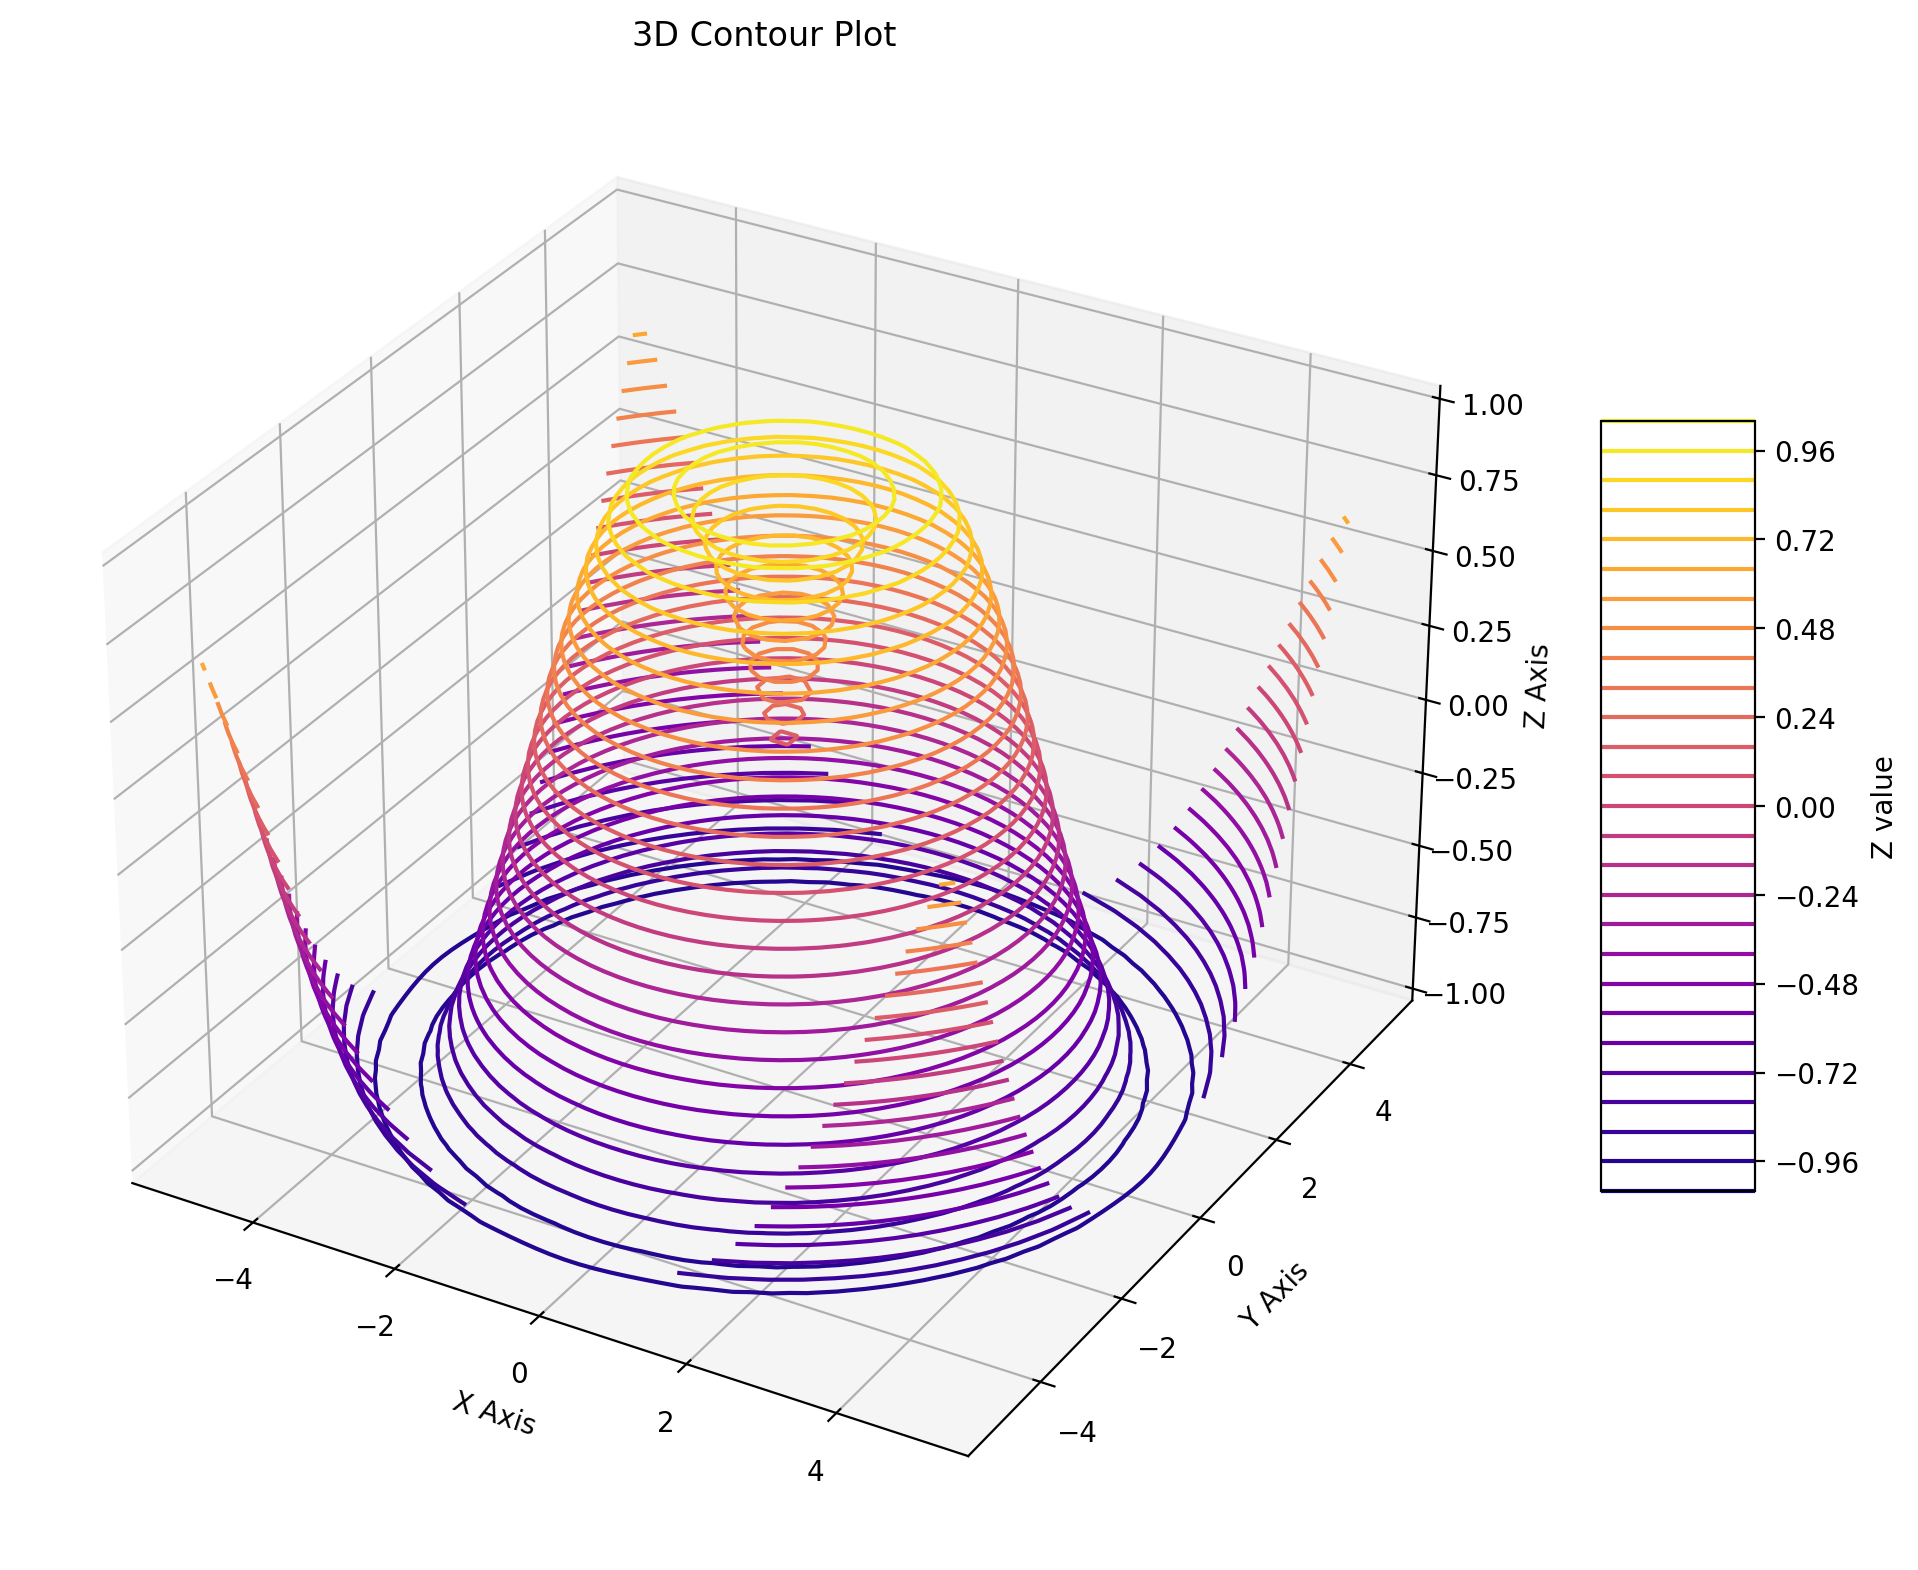

In [ ]:
# 使用曲面图示例中的数据
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sin(R)

# 创建图形和3D坐标轴
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 绘制3D等高线图
# levels 参数指定等高线的数量
contour = ax.contour3D(X, Y, Z, levels=30, cmap='plasma') # 等高线图 <<<======================

# 添加颜色条
cbar = fig.colorbar(contour, ax=ax, shrink=0.5, aspect=5, label='Z value')

# 添加坐标轴标签和标题
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('3D Contour Plot')

plt.show()

定制与美化 3D 图形
绘制出基础图形后，通过一些定制化设置，可以让你的图表更具表现力。

调整视角 👀
通过 ax.view_init(elev, azim) 可以调整 3D 图形的观察角度，这在分析复杂结构时非常有用：

elev：仰角，即视线与水平面（XY平面）的夹角。elev=90 表示从正上方俯视（顶视图），elev=0 表示从侧面平视。

azim：方位角，即视线在水平面（XY平面）内的旋转角度。azim=0 表示看向 X 轴正方向，azim=90 表示看向 Y 轴正方向

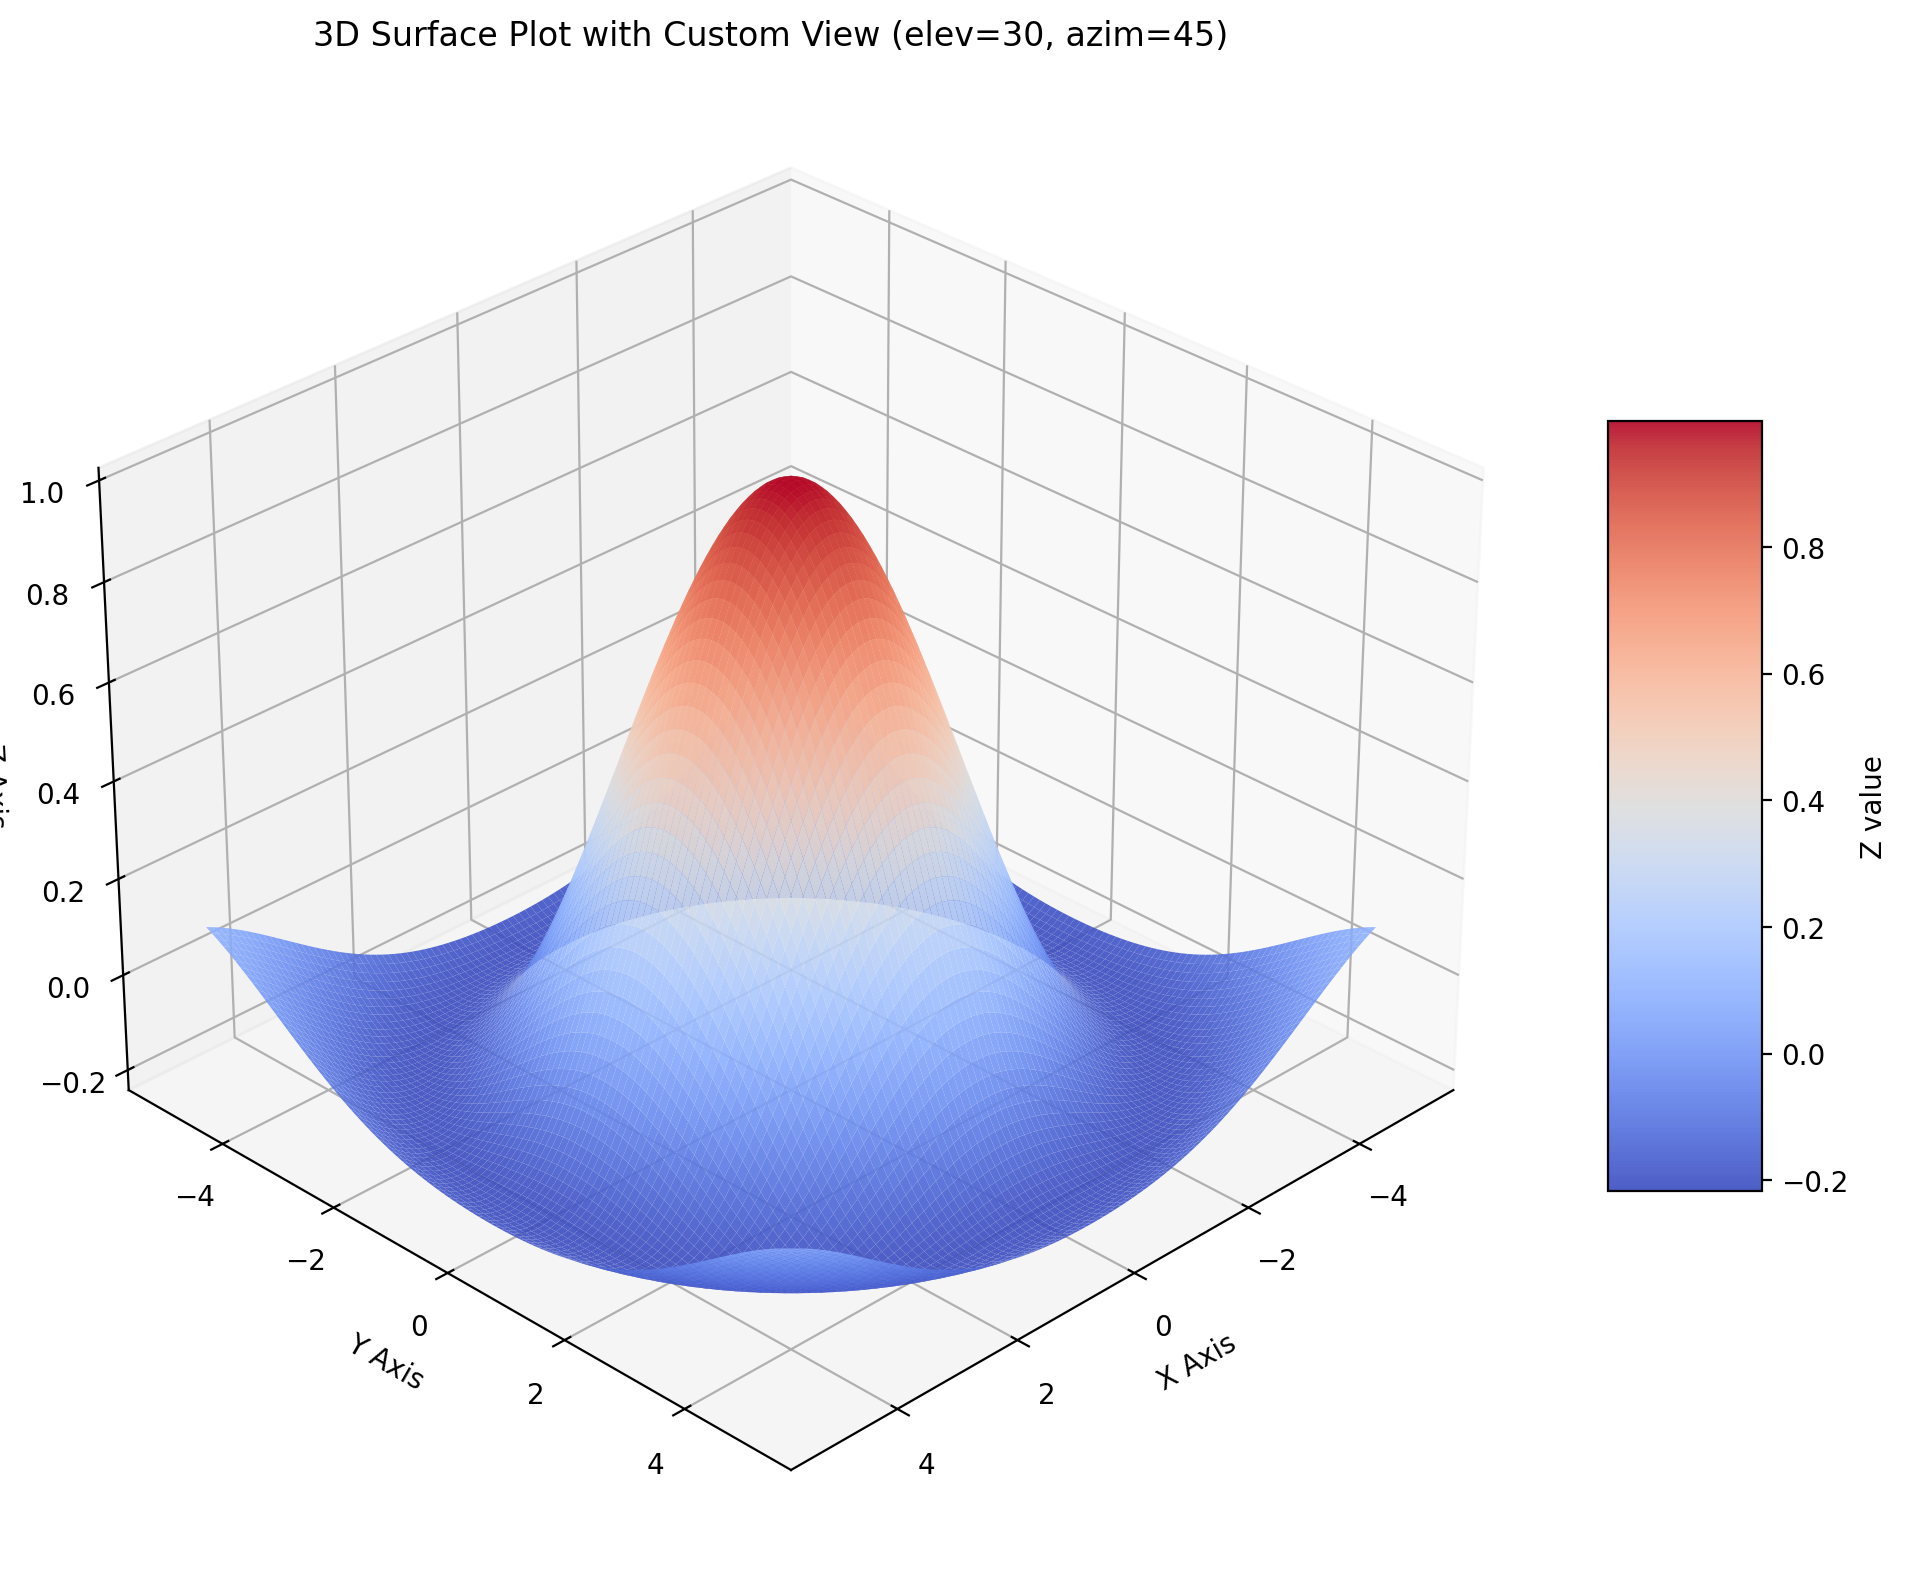

In [19]:
# 绘制一个曲面图，然后调整视角 <<<<========


# ... (此处使用前面曲面图的代码绘制曲面，例如墨西哥帽)
# 生成网格数据
x = np.linspace(-5, 5, 100) # 在-5到5范围内生成100个点
y = np.linspace(-5, 5, 100) 
X, Y = np.meshgrid(x, y) # 将x, y坐标转换为网格矩阵 <<<======================   


# 计算每个网格点上的Z值：这里以墨西哥帽函数为例
R = np.sqrt(X**2 + Y**2) # 计算到原点的距离
Z = np.sin(R) / R # 墨西哥帽函数 (sinc函数)
Z = np.nan_to_num(Z) # 处理原点处可能出现的NaN值

# 创建图形和3D坐标轴
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 绘制3D曲面图
# 参数 cmap 指定颜色映射，rstride 和 cstride 控制行和列的采样步长（已不推荐，推荐使用rcount, ccount）
# antialiased 控制抗锯齿
surface = ax.plot_surface(X, Y, Z, cmap='coolwarm', rcount=100, ccount=100, 
                         linewidth=0, antialiased=True, alpha=0.9)

# 添加颜色条
cbar = fig.colorbar(surface, ax=ax, shrink=0.5, aspect=5, label='Z value')

# 添加坐标轴标签和标题
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('3D Surface Plot - "Mexican Hat" (Sinc Function)')

# 调整观察角度：仰角30度，方位角45度 <<<
ax.view_init(elev=30, azim=45)

ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('3D Surface Plot with Custom View (elev=30, azim=45)')

plt.show()

change Y label 位置， xy label 加数学公式

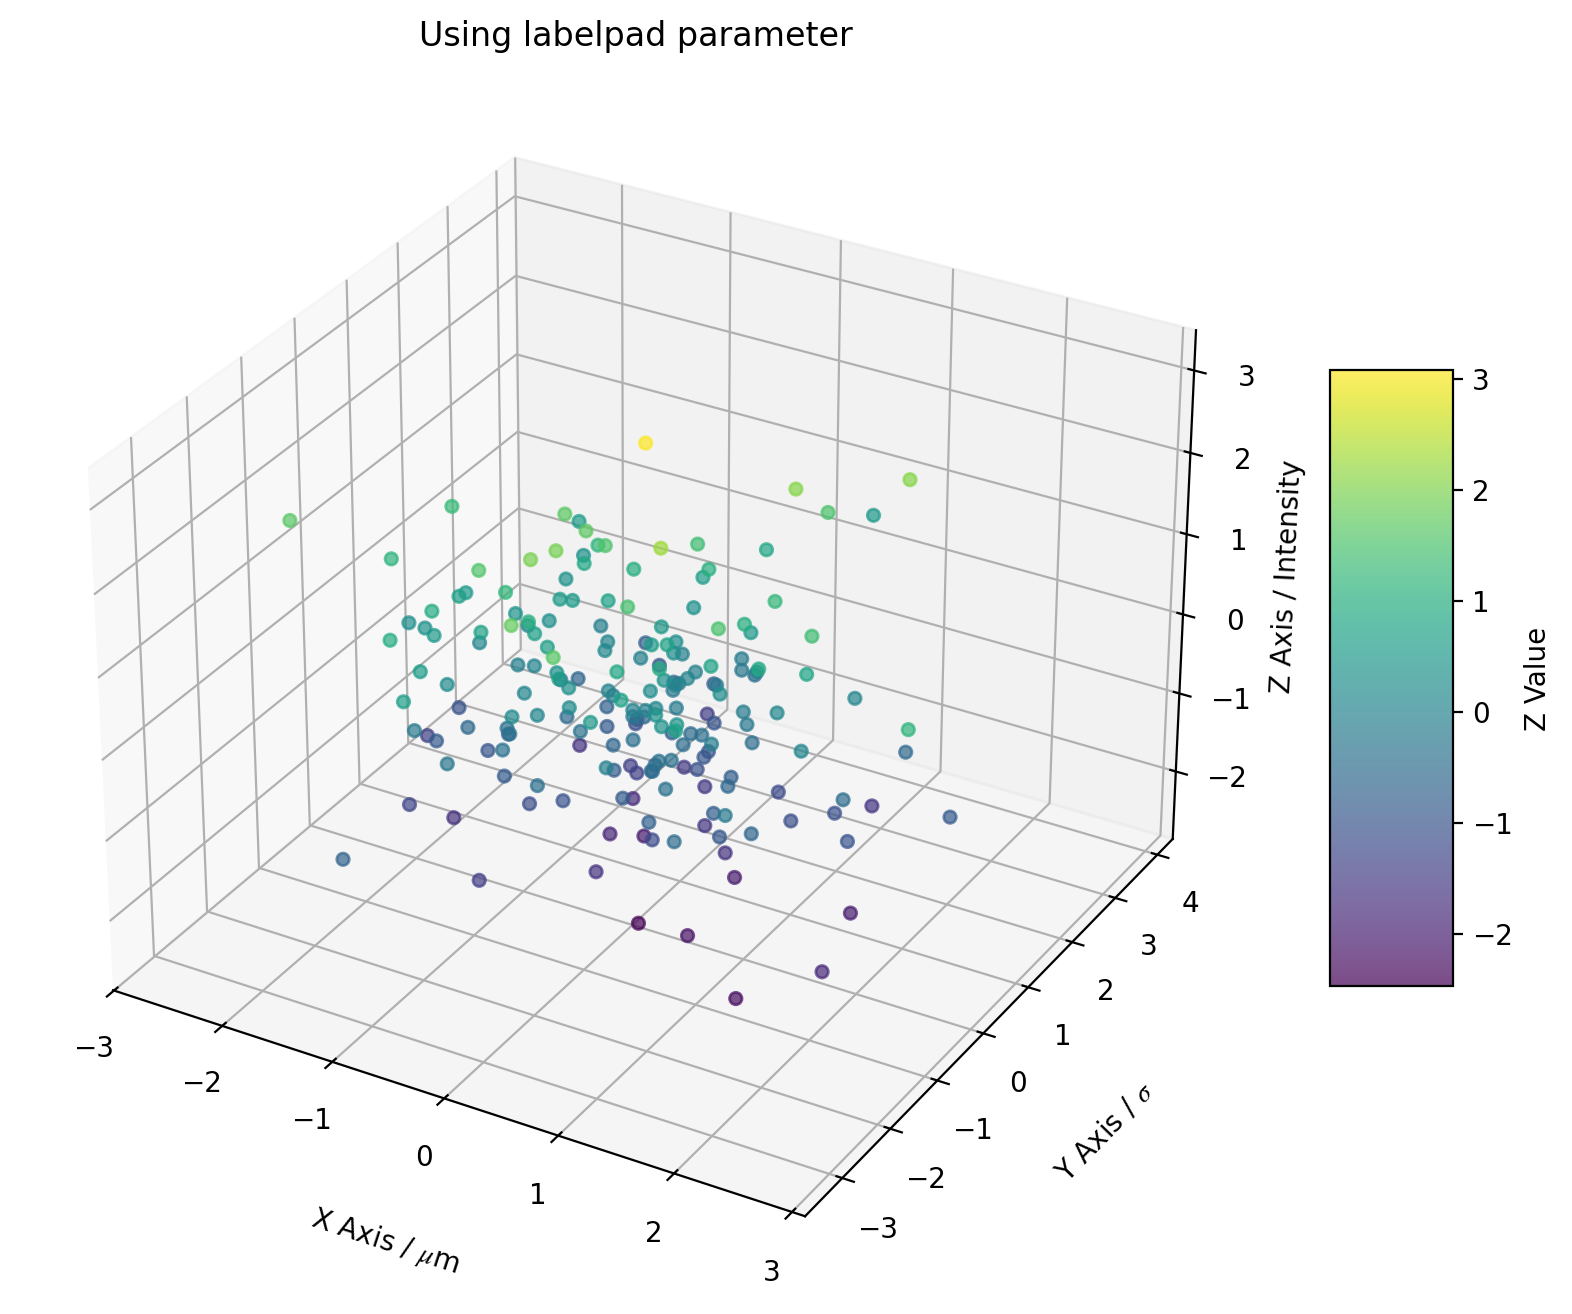

In [27]:
# 在一个散点图示例中添加这些元素


# 生成随机散点数据
np.random.seed(42) # 设置随机种子以便重现结果
num_points = 200
x = np.random.randn(num_points) # 生成服从标准正态分布的随机数作为x坐标
y = np.random.randn(num_points) # y坐标
z = np.random.randn(num_points) # z坐标

# 创建图形和3D坐标轴
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制3D散点图
# 参数 c 可以指定颜色，cmap 指定颜色映射，s 指定点的大小
scatter = ax.scatter(x, y, z, c=z, cmap='viridis', s=20, alpha=0.7) # alpha控制透明度 <<+++++++++++++

# 添加颜色条，表示Z值的大小
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=5, label='Z Value')

# 添加坐标轴标签和标题
# ax.set_xlabel('X Axis')
# ax.set_ylabel('Y Axis')
# ax.set_zlabel('Z Axis')
# ax.set_title('3D Scatter Plot with Colormap')
# plt.show()  <<<+++++++++++++  很奇怪的是，一旦显示，下面的自定义就不起作用了 <<=======

# 添加坐标轴标签 (可以使用LaTeX语法渲染数学符号)
ax.set_xlabel('X Axis / $\\mu$m', labelpad=15) # labelpad可以调整标签与坐标轴的距离
ax.set_ylabel('Y Axis / $\\sigma$', labelpad=15)
ax.set_zlabel('Z Axis / Intensity', labelpad=2) #  reduce Z轴标签距离 <<<+++++++++++++

ax.set_title('Using labelpad parameter')

# 添加标题
#ax.set_title('Customized 3D Scatter Plot', pad=20) # pad调整标题与图形的距离

# 如果你在绘图时指定了label，可以显示图例
# 例如：ax.scatter(..., label='Data Points 1')
# ax.legend(loc='upper right')

plt.show()

网格图 (Wireframe Plot)

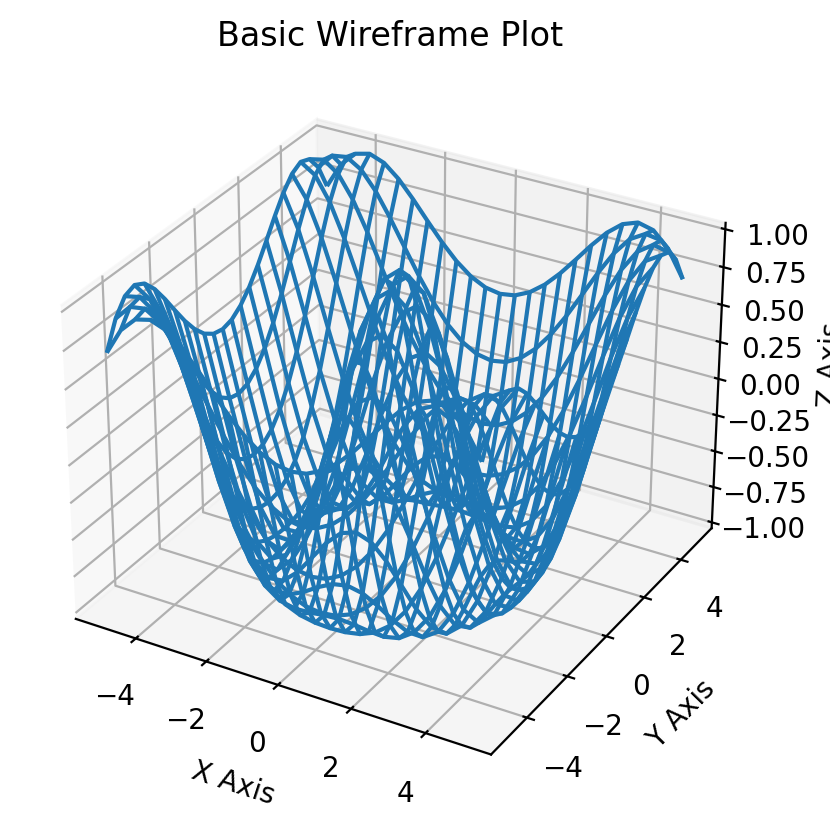

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create data points
x = np.linspace(-5, 5, 25)
y = np.linspace(-5, 5, 25)
# Generate a 2D grid from the 1D arrays
X, Y = np.meshgrid(x, y)
# Define Z as a function of X and Y (e.g., a cosine wave)
Z = np.cos(np.sqrt(X**2 + Y**2))

# Create the plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# Plot the wireframe
ax.plot_wireframe(X, Y, Z) #网格图 (Wireframe Plot) <<<======================
# Add labels and title
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('Basic Wireframe Plot')

plt.show()

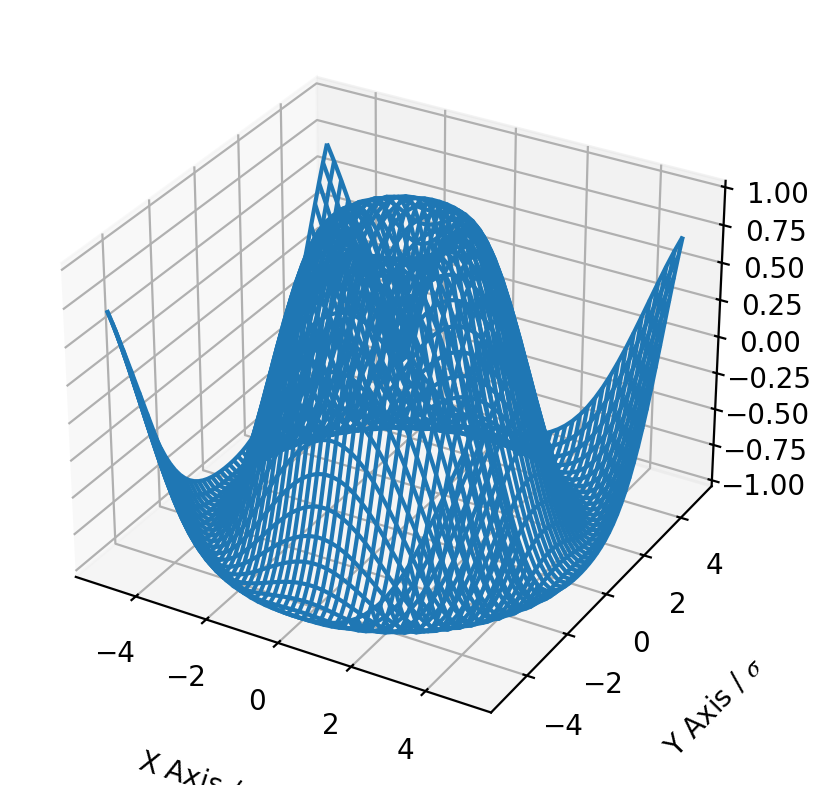

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 使用Matplotlib内置的数学文本渲染
plt.rcParams.update({
    "mathtext.fontset": "stix",  # 或者 "cm", "dejavusans", "dejavuserif"
})

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 示例数据
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

ax.plot_wireframe(X, Y, Z) # 网格图 (Wireframe Plot) <<<======================

# 使用LaTeX语法 - MathText支持基本的LaTeX数学符号
ax.set_xlabel(r'X Axis / $\mu$m', labelpad=15)        # 注意前面的 r
ax.set_ylabel(r'Y Axis / $\sigma$', labelpad=15)      # 注意前面的 r  
ax.set_zlabel(r'Z Axis / $Intensity$', labelpad=15)   # 注意前面的 r

plt.show()

不同距离的 labelpad 效果

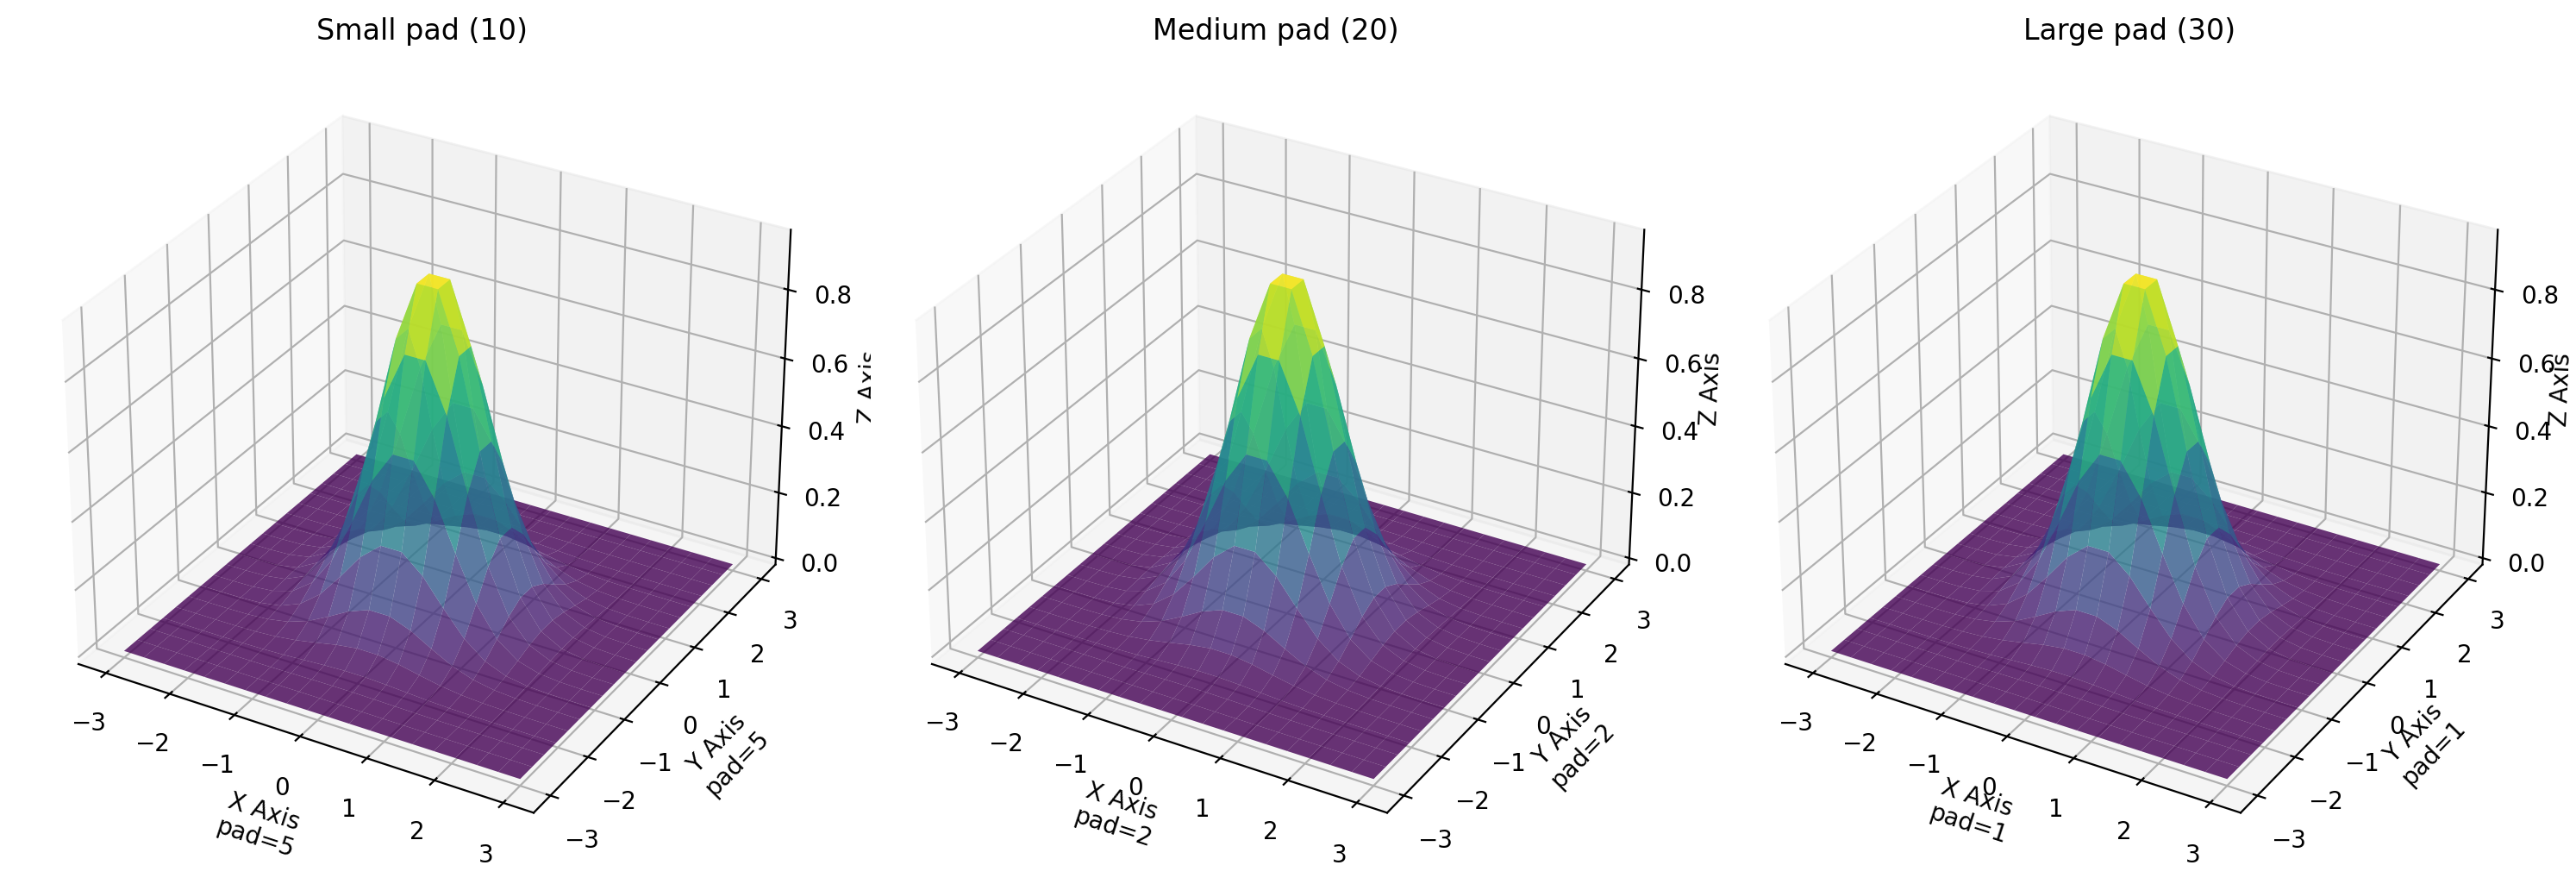

In [30]:
fig = plt.figure(figsize=(15, 5))

# 不同 labelpad 值的对比
pads = [5, 2, 1]
titles = ['Small pad (10)', 'Medium pad (20)', 'Large pad (30)']

for i, pad in enumerate(pads, 1):
    ax = fig.add_subplot(1, 3, i, projection='3d')
    
    # 简单曲面
    x = np.linspace(-3, 3, 20)
    y = np.linspace(-3, 3, 20)
    X, Y = np.meshgrid(x, y)
    Z = np.exp(-(X**2 + Y**2))
    
    ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
    
    # 应用不同的 labelpad
    ax.set_xlabel(f'X Axis\npad={pad}', labelpad=pad)
    ax.set_ylabel(f'Y Axis\npad={pad}', labelpad=pad)
    ax.set_zlabel(f'Z Axis\npad={pad}', labelpad=pad)
    
    ax.set_title(titles[i-1])

plt.tight_layout()
plt.show()

对于更精细的控制，可以直接操作标签对象：

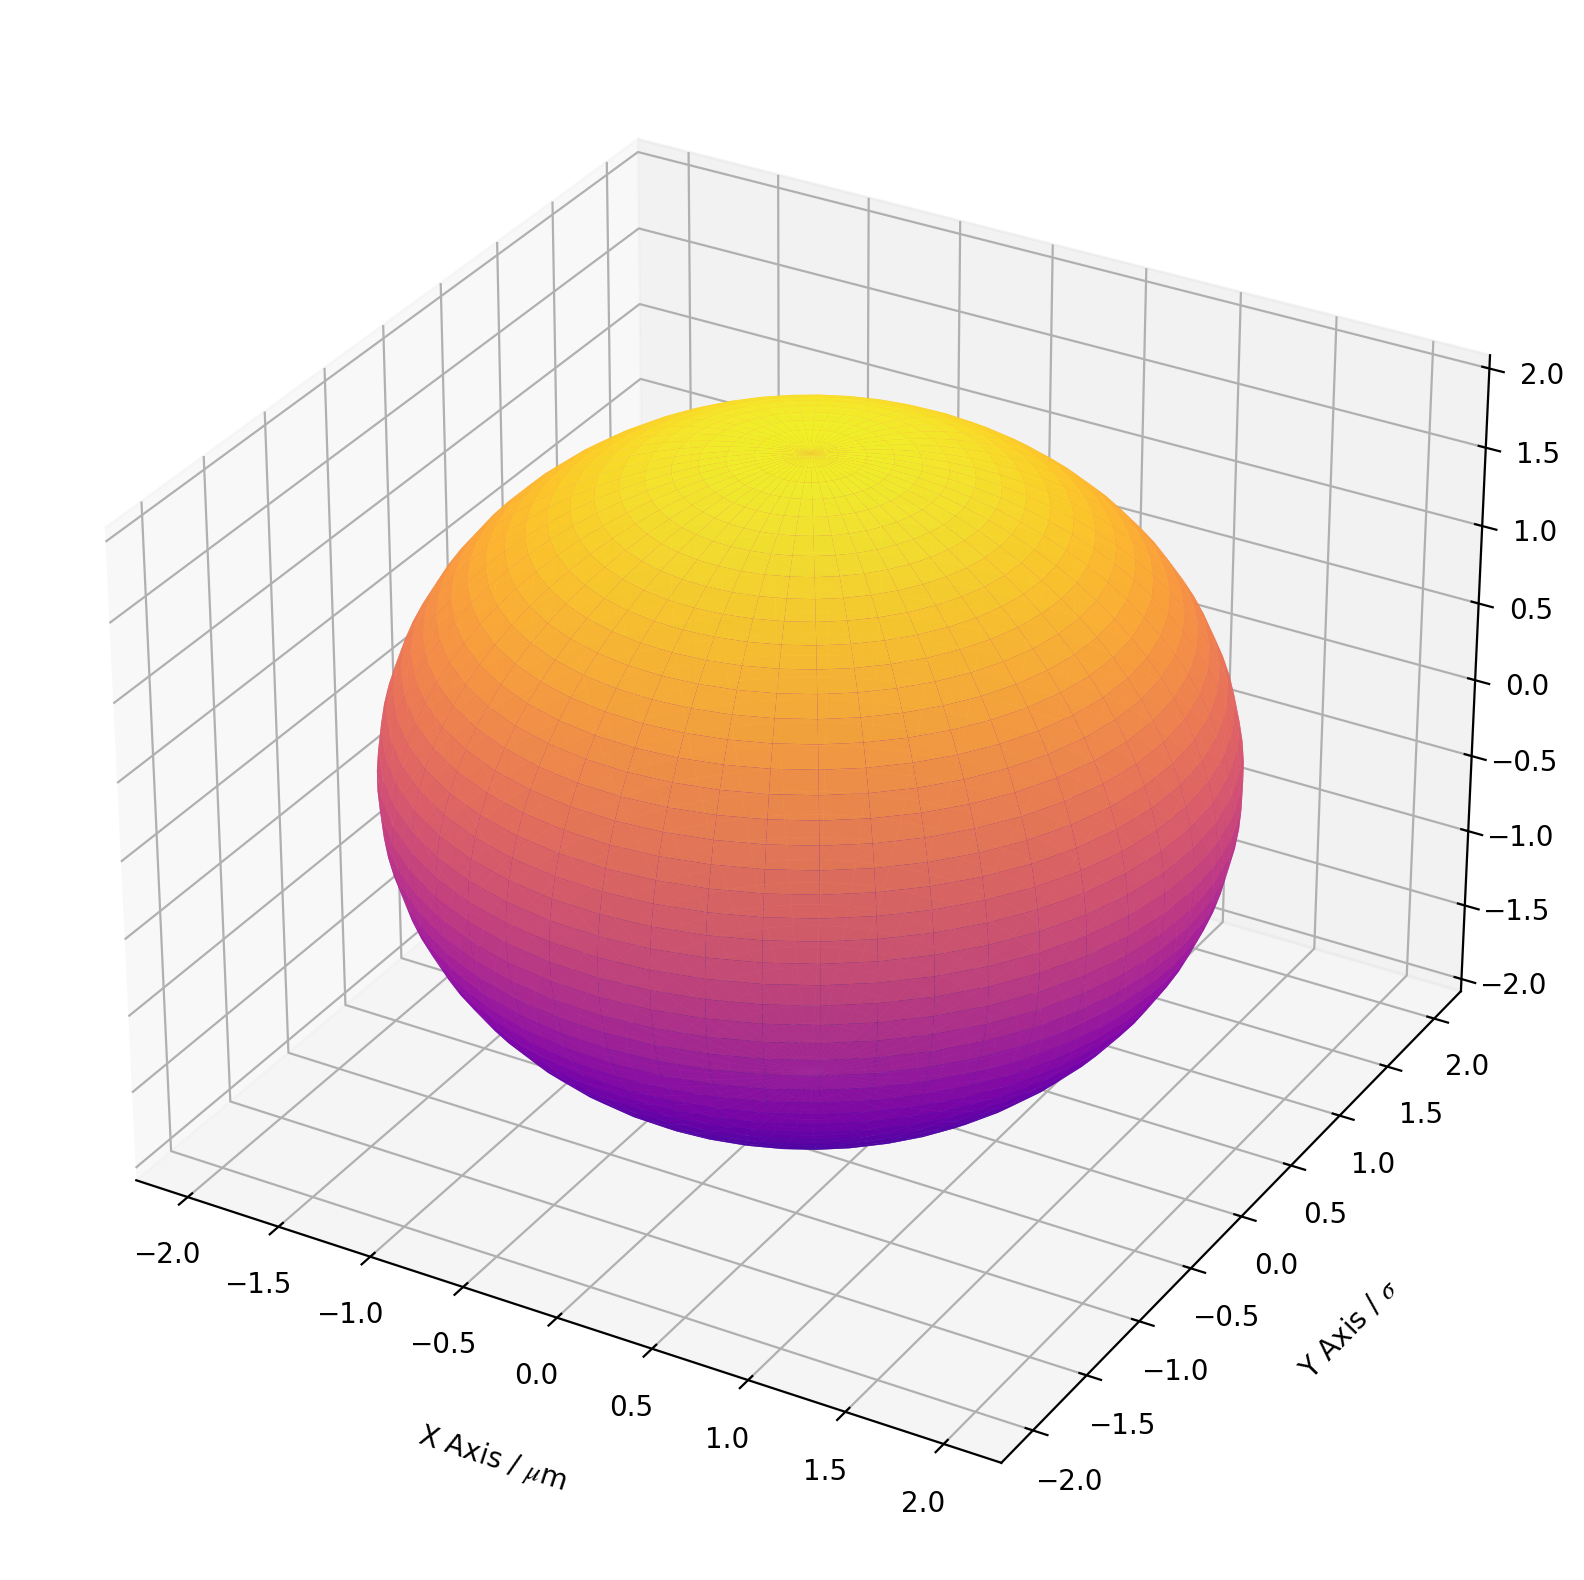

In [32]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 创建更复杂的数据
u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 50)
U, V = np.meshgrid(u, v)

X = 2 * np.cos(U) * np.sin(V)
Y = 2 * np.sin(U) * np.sin(V)
Z = 2 * np.cos(V)

ax.plot_surface(X, Y, Z, cmap='plasma', alpha=0.9)

# 设置标签并获取标签对象
xlabel = ax.set_xlabel('X Axis / $\\mu$m', labelpad=15)
ylabel = ax.set_ylabel('Y Axis / $\\sigma$', labelpad=15)
zlabel = ax.set_zlabel('Z Axis / Intensity', labelpad=15)

# 手动调整位置（需要转换坐标）
ax.xaxis.label.set_position((0, 1))  # 调整X标签位置
ax.yaxis.label.set_position((0, 1))  # 调整Y标签位置

plt.show()

旋转标签以获得更好可读性

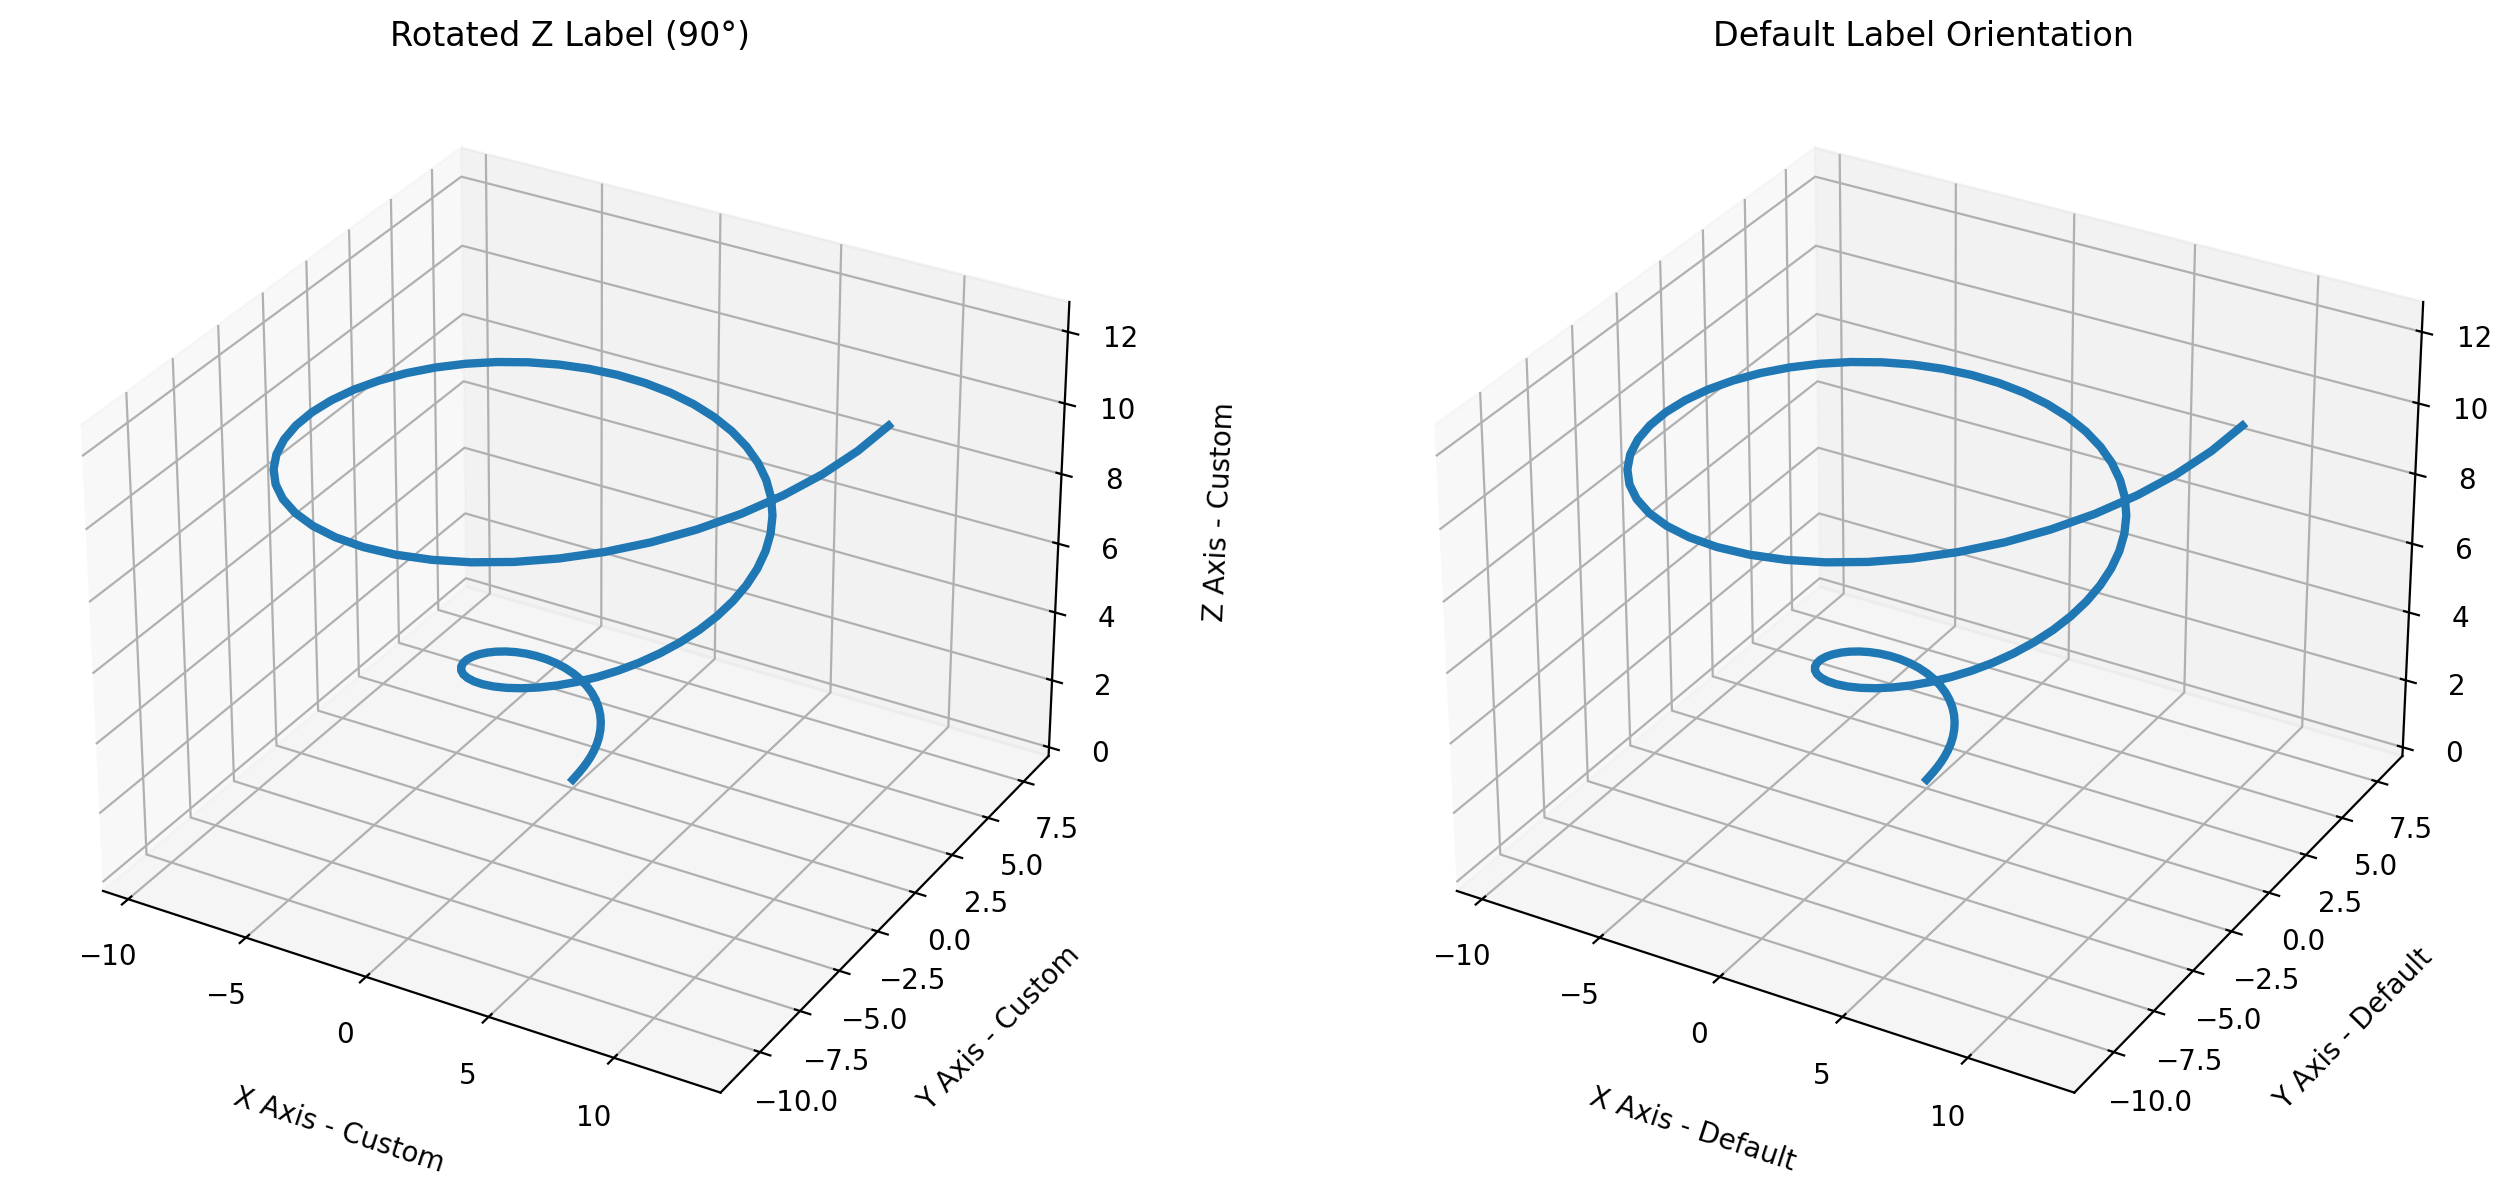

In [35]:
fig = plt.figure(figsize=(14, 6))

# 创建两个子图对比
for i in range(2):
    ax = fig.add_subplot(1, 2, i+1, projection='3d')
    
    # 螺旋数据
    t = np.linspace(0, 4*np.pi, 100)
    x = t * np.cos(t)
    y = t * np.sin(t)
    z = t
    
    ax.plot(x, y, z, linewidth=3)
    
    if i == 1:
        # 默认标签
        ax.set_xlabel('X Axis - Default', labelpad=15)
        ax.set_ylabel('Y Axis - Default', labelpad=15)
        ax.set_zlabel('Z Axis - Default', labelpad=15)
        ax.set_title('Default Label Orientation')
    else:
        # 旋转Z轴标签
        ax.set_xlabel('X Axis - Custom', labelpad=15)
        ax.set_ylabel('Y Axis - Custom', labelpad=15)
        zlabel = ax.set_zlabel('Z Axis - Custom', labelpad=15, rotation=45) # 旋转90度 =================================
        ax.set_title('Rotated Z Label (90°)')

plt.tight_layout()
plt.show()

6. 多子图标签位置优化

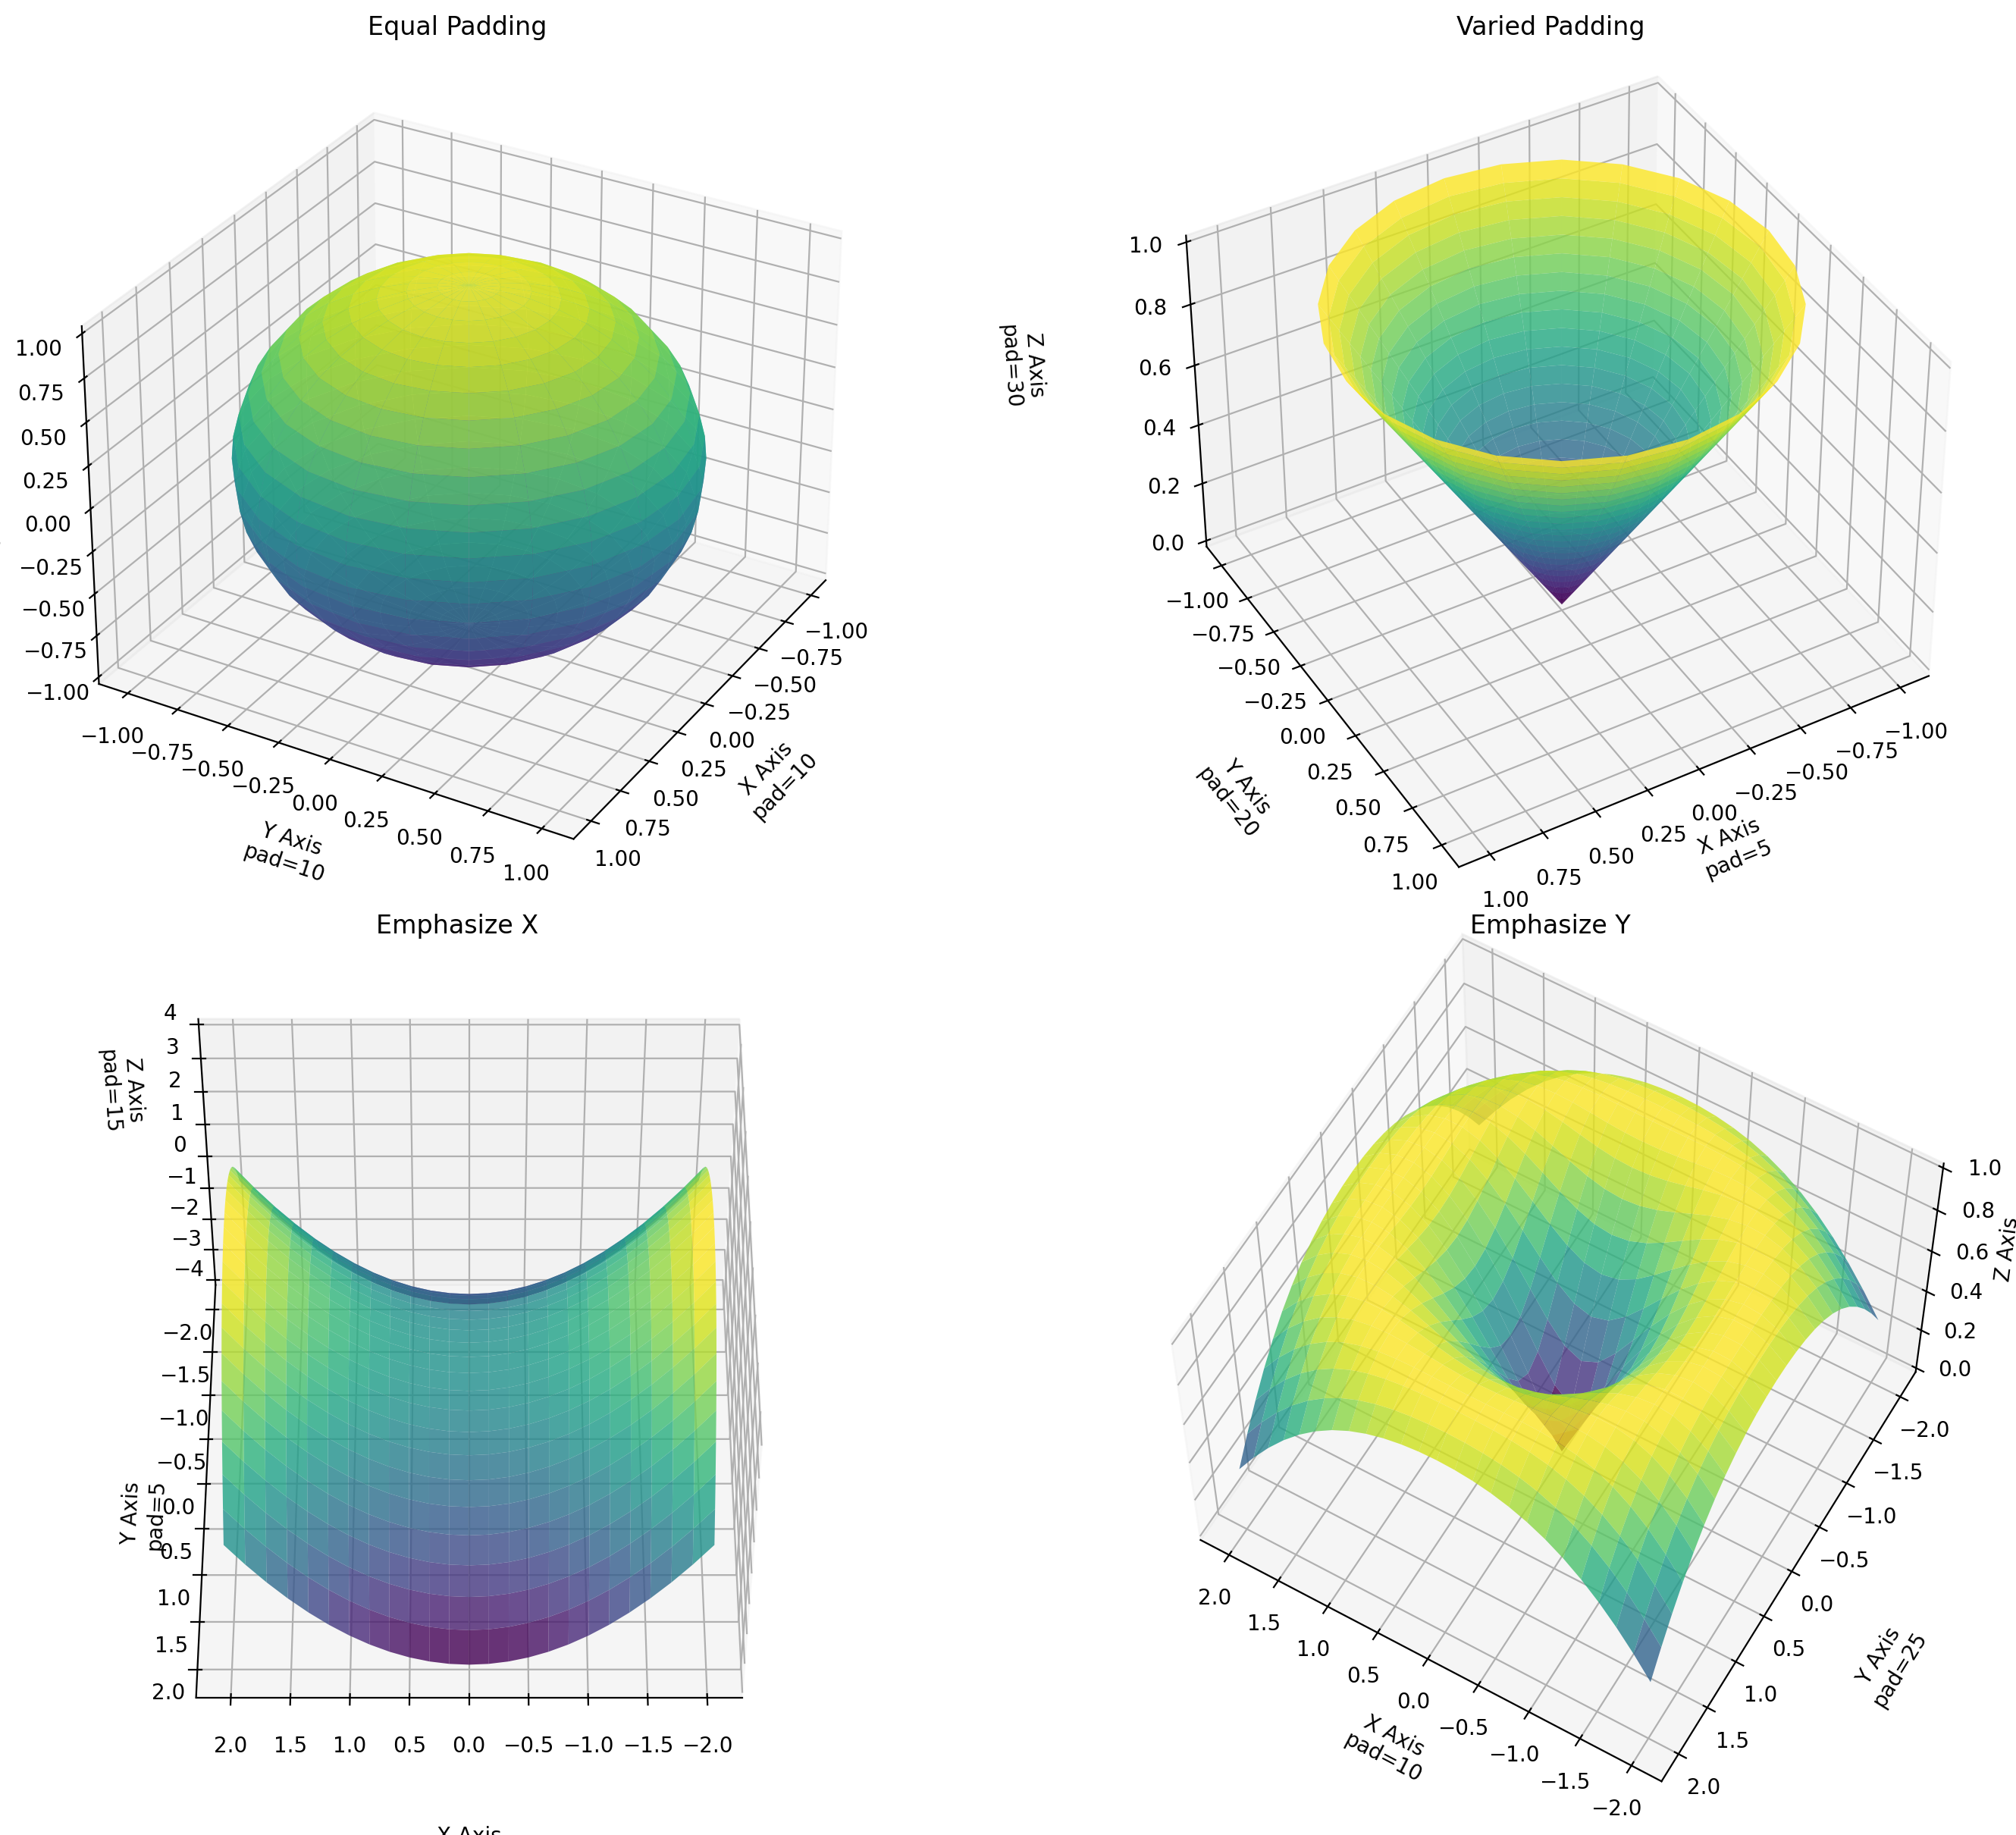

In [36]:
fig = plt.figure(figsize=(16, 12))

# 创建4个不同配置的子图
configs = [
    {'xpad': 10, 'ypad': 10, 'zpad': 10, 'title': 'Equal Padding'},
    {'xpad': 5, 'ypad': 20, 'zpad': 30, 'title': 'Varied Padding'},
    {'xpad': 25, 'ypad': 5, 'zpad': 15, 'title': 'Emphasize X'},
    {'xpad': 10, 'ypad': 25, 'zpad': 5, 'title': 'Emphasize Y'}
]

for i, config in enumerate(configs, 1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    
    # 生成不同的3D形状
    if i == 1:
        # 球体
        u = np.linspace(0, 2 * np.pi, 25)
        v = np.linspace(0, np.pi, 25)
        U, V = np.meshgrid(u, v)
        X = np.cos(U) * np.sin(V)
        Y = np.sin(U) * np.sin(V)
        Z = np.cos(V)
    elif i == 2:
        # 锥体
        r = np.linspace(0, 1, 25)
        theta = np.linspace(0, 2*np.pi, 25)
        R, Theta = np.meshgrid(r, theta)
        X = R * np.cos(Theta)
        Y = R * np.sin(Theta)
        Z = R
    elif i == 3:
        # 马鞍面
        x = np.linspace(-2, 2, 25)
        y = np.linspace(-2, 2, 25)
        X, Y = np.meshgrid(x, y)
        Z = X**2 - Y**2
    else:
        # 波纹面
        x = np.linspace(-2, 2, 25)
        y = np.linspace(-2, 2, 25)
        X, Y = np.meshgrid(x, y)
        Z = np.sin(np.sqrt(X**2 + Y**2))
    
    ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
    
    # 应用配置
    ax.set_xlabel(f'X Axis\npad={config["xpad"]}', 
                  labelpad=config['xpad'])
    ax.set_ylabel(f'Y Axis\npad={config["ypad"]}', 
                  labelpad=config['ypad'])
    ax.set_zlabel(f'Z Axis\npad={config["zpad"]}', 
                  labelpad=config['zpad'])
    
    ax.set_title(config['title'])
    
    # 为每个子图设置不同的视角
    ax.view_init(elev=20 + i*10, azim=i*30)

plt.tight_layout()
plt.show()